In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("环境正常 ✓")

环境正常 ✓


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
from matplotlib import font_manager
import seaborn as sns
import re
from collections import Counter

# 中文字体支持（macOS / Windows / Linux）
cjk_font_candidates = [
    'Heiti TC', 'Songti SC', 'PingFang SC', 'Arial Unicode MS',
    'Noto Sans CJK SC', 'Microsoft YaHei', 'SimHei'
]
available_fonts = {font.name for font in font_manager.fontManager.ttflist}
for font_name in cjk_font_candidates:
    if font_name in available_fonts:
        matplotlib.rcParams['font.family'] = 'sans-serif'
        matplotlib.rcParams['font.sans-serif'] = [font_name, 'DejaVu Sans']
        break
matplotlib.rcParams['axes.unicode_minus'] = False

# 加载数据
contents = pd.read_csv('csv/search_contents_2026-04-08.csv')
comments = pd.read_csv('csv/search_comments_2026-04-08.csv')

print(f'笔记: {contents.shape}')
print(f'评论: {comments.shape}')
contents.head(3)

笔记: (160, 21)
评论: (1916, 13)


,note_id,type,title,desc,video_url,time,last_update_time,user_id,nickname,avatar,...,collected_count,comment_count,share_count,ip_location,image_list,tag_list,last_modify_ts,note_url,source_keyword,xsec_token
0,6911eccc0000000007036a2a,video,这个谁用谁知道,#日常[话题]#,http://sns-video-alos.xhscdn.com/stream/1/110/...,1762782412000,1766113519000,68a2939200000000190212d2,兑现春天,https://sns-avatar-qc.xhscdn.com/avatar/1040g2...,...,713.0,211.0,1590.0,NaN,http://sns-webpic-qc.xhscdn.com/202604082219/2...,日常,1775658006548,https://www.xiaohongshu.com/explore/6911eccc00...,宝拉珍选,ABarF9QTcIKLdfaH-xe20AG535McWUzFqIHAeAojr7c74=
1,6961fe8c000000001a023769,video,皮肤博士1句话点评平价A醇🈚️广纯分享,你用过哪一款？\n@露得清\n@Paula's Choice宝拉珍选\n@CeraVe适乐肤...,http://sns-video-alos.xhscdn.com/stream/79/110...,1768042561000,1768065154000,60ba4337000000000100194d,DermTalk,https://sns-avatar-qc.xhscdn.com/avatar/1040g2...,...,5415.0,83.0,387.0,NaN,http://sns-webpic-qc.xhscdn.com/202604082219/b...,"护肤分享,精简护肤,早C晚A,A醇,精华,面霜,寻找美护新玩家,我的护肤日常",1775658006551,https://www.xiaohongshu.com/explore/6961fe8c00...,宝拉珍选,ABnBdRlCdw0yDV7l6XbK3PTOfXZwBuxztK_2xJwimyx70=
2,60ea7f8d000000000102e905,normal,宝拉珍选水杨酸！磨皮（去油脂粒）王者,用一片化妆棉，吸满这个液体，先轻擦两侧脸颊几次，然后敷在鼻子上大概四五分钟吧，再把化妆棉放在...,NaN,1625980813000,1731489264000,5fb994d4000000000101ce47,butter honey 小红薯🍠🍠,https://sns-avatar-qc.xhscdn.com/avatar/1040g2...,...,1871.0,60.0,330.0,NaN,http://sns-webpic-qc.xhscdn.com/202604082219/4...,NaN,1775658006551,https://www.xiaohongshu.com/explore/60ea7f8d00...,宝拉珍选,ABppJ_hp8dEo03LE82VH0HXky4CrtJDyhQ2MaZNQvgUQE=


In [3]:
print("=== 笔记字段缺失情况 ===")
print(contents.isnull().sum())
print()
print("=== 评论字段缺失情况 ===")
print(comments.isnull().sum())

=== 笔记字段缺失情况 ===
note_id               0
type                  0
title                 0
desc                  0
video_url           145
time                  0
last_update_time      0
user_id               0
nickname              0
avatar                0
liked_count           0
collected_count       1
comment_count         7
share_count           7
ip_location         155
image_list            0
tag_list             78
last_modify_ts        0
note_url              0
source_keyword        0
xsec_token            0
dtype: int64

=== 评论字段缺失情况 ===
comment_id              0
create_time             0
ip_location           529
note_id                 0
content                 2
user_id                 0
nickname                0
avatar                  0
sub_comment_count       0
pictures             1870
parent_comment_id       0
last_modify_ts          0
like_count              0
dtype: int64


In [4]:
# liked_count 含"万"，转成数字
def parse_liked(x):
    if pd.isna(x): return 0
    x = str(x).strip()
    if '万' in x:
        return float(x.replace('万', '')) * 10000
    try:
        return float(x)
    except:
        return 0

contents['liked_count_num'] = contents['liked_count'].apply(parse_liked)

# 时间戳（毫秒）转可读时间
contents['publish_time'] = pd.to_datetime(contents['time'], unit='ms')
comments['create_dt'] = pd.to_datetime(comments['create_time'], unit='ms')

# 内容长度
contents['title_len'] = contents['title'].str.len()
contents['desc_len'] = contents['desc'].str.len()
comments['content_len'] = comments['content'].fillna('').str.len()

# 去重（同一篇笔记被多个关键词爬到）
contents_dedup = contents.drop_duplicates(subset='note_id').copy()

# 删除空评论
comments_clean = comments.dropna(subset=['content']).copy()

print(f'笔记去重后: {len(contents_dedup)} 条')
print(f'有效评论: {len(comments_clean)} 条')

笔记去重后: 118 条
有效评论: 1914 条


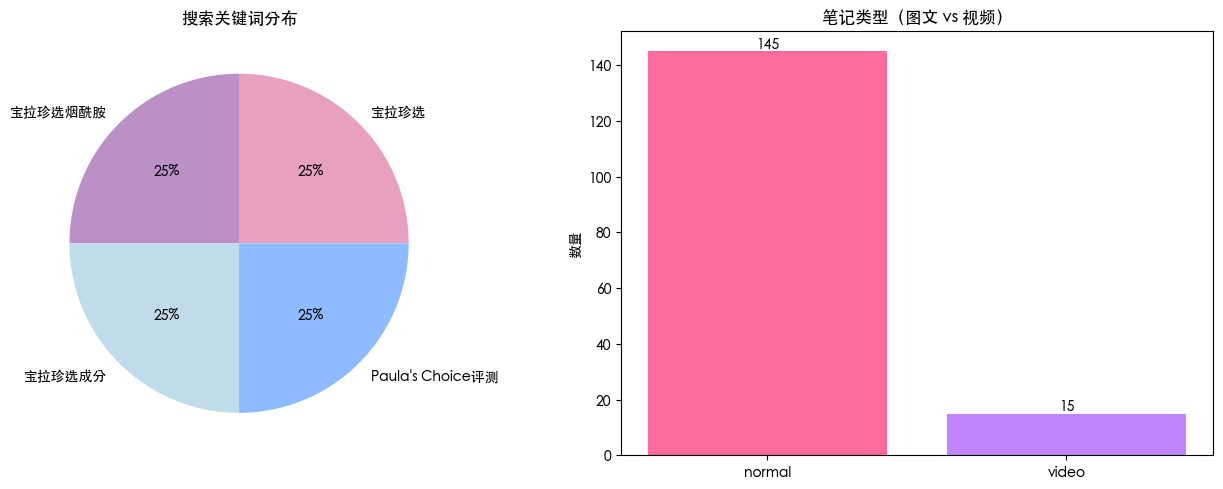

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# 左图：搜索关键词分布
kw = contents['source_keyword'].value_counts()
axes[0].pie(kw.values, labels=kw.index, autopct='%1.0f%%',
            colors=['#E8A0BF','#BA90C6','#C0DBEA','#8EBBFF'])
axes[0].set_title('搜索关键词分布')

# 右图：图文 vs 视频
tc = contents['type'].value_counts()
axes[1].bar(tc.index, tc.values, color=['#FF6B9D','#C084FC'])
axes[1].set_title('笔记类型（图文 vs 视频）')
axes[1].set_ylabel('数量')
for i, v in enumerate(tc.values):
    axes[1].text(i, v+1, str(v), ha='center')

plt.tight_layout()
plt.show()


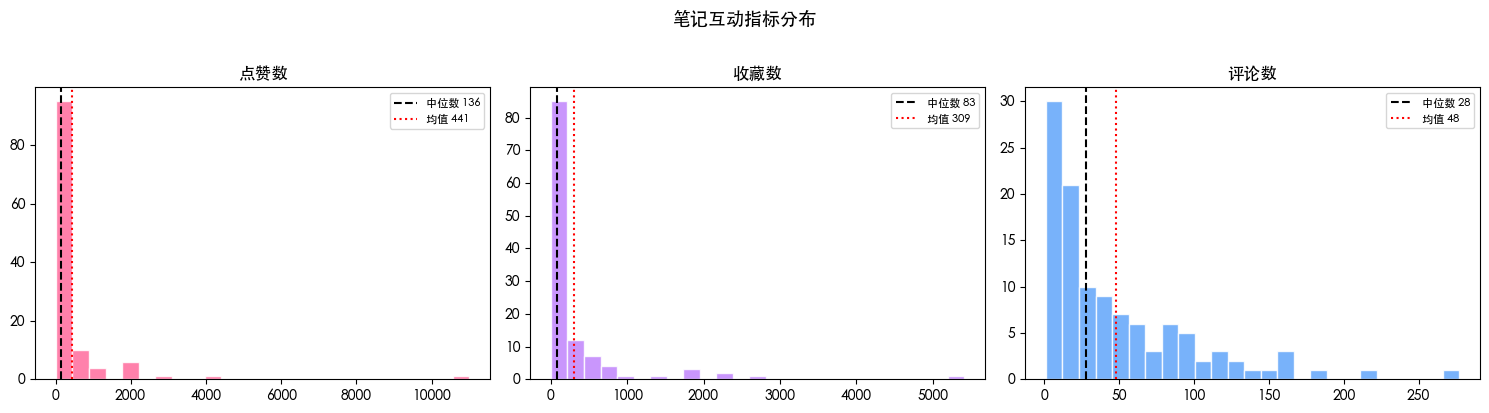

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

metrics = [
    ('liked_count_num', '点赞数', '#FF6B9D'),
    ('collected_count', '收藏数', '#C084FC'),
    ('comment_count',  '评论数', '#60A5FA'),
]

for ax, (col, label, color) in zip(axes, metrics):
    data = contents_dedup[col].dropna()
    ax.hist(data, bins=25, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(data.median(), color='black', linestyle='--', linewidth=1.5,
               label=f'中位数 {data.median():.0f}')
    ax.axvline(data.mean(), color='red', linestyle=':', linewidth=1.5,
               label=f'均值 {data.mean():.0f}')
    ax.set_title(label)
    ax.legend(fontsize=8)

plt.suptitle('笔记互动指标分布', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

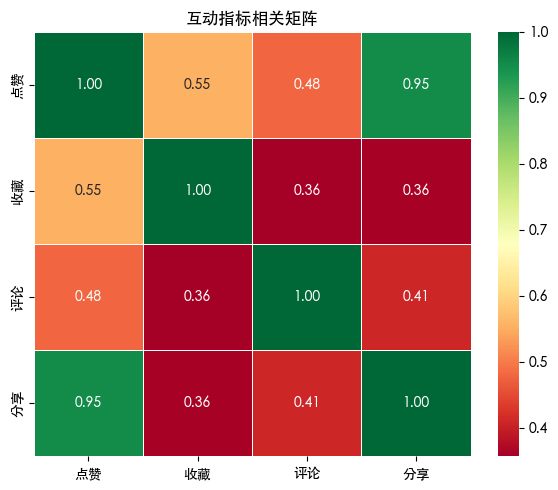

In [7]:
corr = contents_dedup[['liked_count_num','collected_count',
                        'comment_count','share_count']].dropna().corr()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            xticklabels=['点赞','收藏','评论','分享'],
            yticklabels=['点赞','收藏','评论','分享'],
            linewidths=0.5, ax=ax)
ax.set_title('互动指标相关矩阵')
plt.tight_layout()
plt.show()

In [8]:
top10 = contents_dedup.nlargest(10, 'liked_count_num')[
    ['title','liked_count_num','collected_count','comment_count','type']
].reset_index(drop=True)
top10.index += 1
top10.columns = ['标题','点赞','收藏','评论','类型']
top10['标题'] = top10['标题'].str[:20] + '...'
top10

,标题,点赞,收藏,评论,类型
1,这个谁用谁知道...,11000.0,713.0,211.0,video
2,皮肤博士1句话点评平价A醇🈚️广纯分享...,4188.0,5415.0,83.0,video
3,干货｜这些成分不要乱组合，小心烂脸😱...,2691.0,2616.0,38.0,normal
4,烂脸期成功上岸✨北美高性价比祛痘急救清单...,2112.0,2357.0,49.0,video
5,宝拉珍选水杨酸！磨皮（去油脂粒）王者...,1921.0,1871.0,60.0,normal
6,0元领取重磅新品！！绝绝紫精华真的绝！...,1917.0,1895.0,163.0,normal
7,油皮、痘痘皮最爱的宝拉珍选，什么最值得买...,1908.0,2186.0,95.0,normal
8,宝拉2% 水杨酸正确用法...,1843.0,1868.0,277.0,normal
9,不是我吹这两我能用一辈子...,1801.0,1348.0,111.0,normal
10,皮肤博士的宝拉珍选Top 5爱用品❤️...,1154.0,733.0,47.0,video


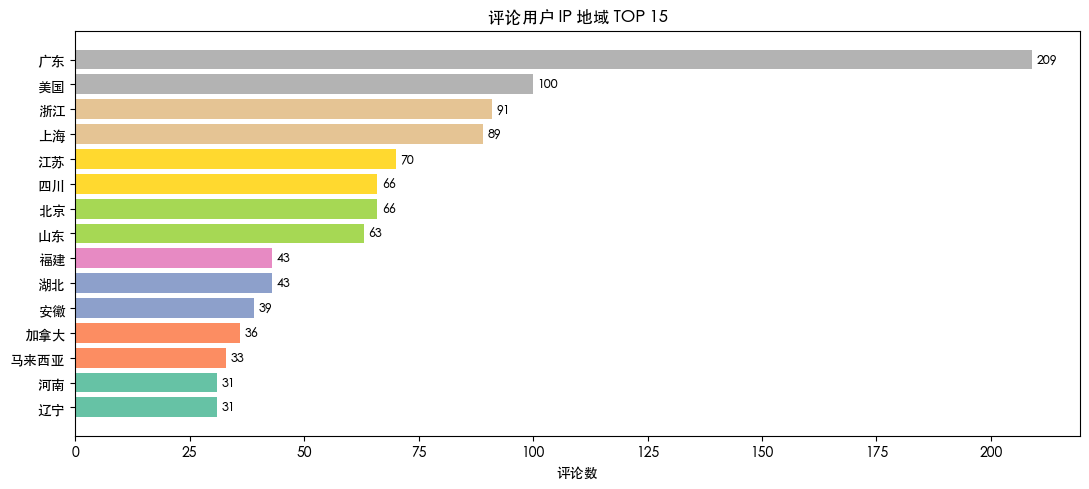

In [9]:
loc = comments_clean['ip_location'].dropna().value_counts().head(15)

fig, ax = plt.subplots(figsize=(11, 5))
import numpy as np
bars = ax.barh(loc.index[::-1], loc.values[::-1],
               color=plt.cm.Set2(np.linspace(0,1,15)))
ax.set_xlabel('评论数')
ax.set_title('评论用户 IP 地域 TOP 15')
for bar, v in zip(bars, loc.values[::-1]):
    ax.text(bar.get_width()+1, bar.get_y()+bar.get_height()/2,
            str(v), va='center', fontsize=9)
plt.tight_layout()
plt.show()

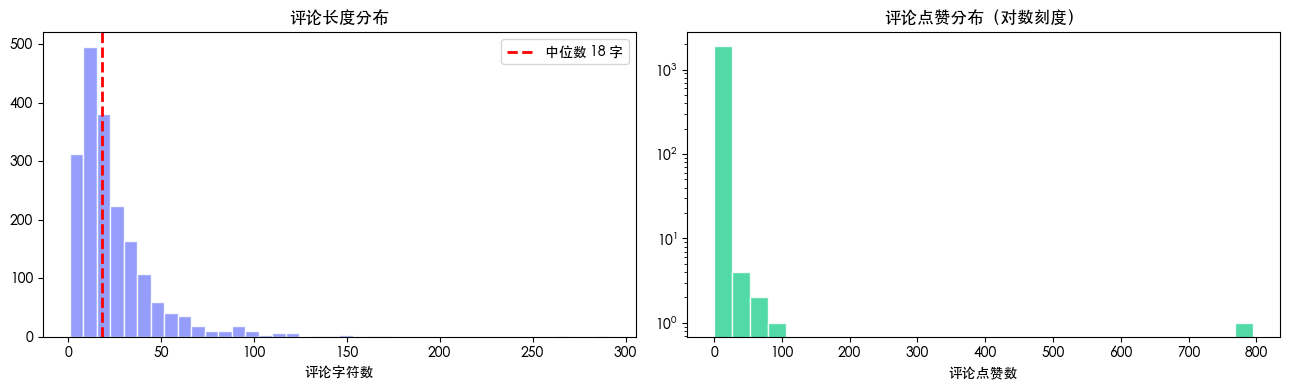

点赞为0的评论占: 65.7%


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(comments_clean['content_len'], bins=40,
             color='#818CF8', edgecolor='white', alpha=0.85)
axes[0].axvline(comments_clean['content_len'].median(), color='red',
                linestyle='--', linewidth=2,
                label=f"中位数 {comments_clean['content_len'].median():.0f} 字")
axes[0].set_xlabel('评论字符数')
axes[0].set_title('评论长度分布')
axes[0].legend()

axes[1].hist(comments_clean['like_count'], bins=30,
             color='#34D399', edgecolor='white', alpha=0.85)
axes[1].set_yscale('log')
axes[1].set_xlabel('评论点赞数')
axes[1].set_title('评论点赞分布（对数刻度）')

plt.tight_layout()
plt.show()

zero_pct = (comments_clean['like_count']==0).mean()*100
print(f'点赞为0的评论占: {zero_pct:.1f}%')

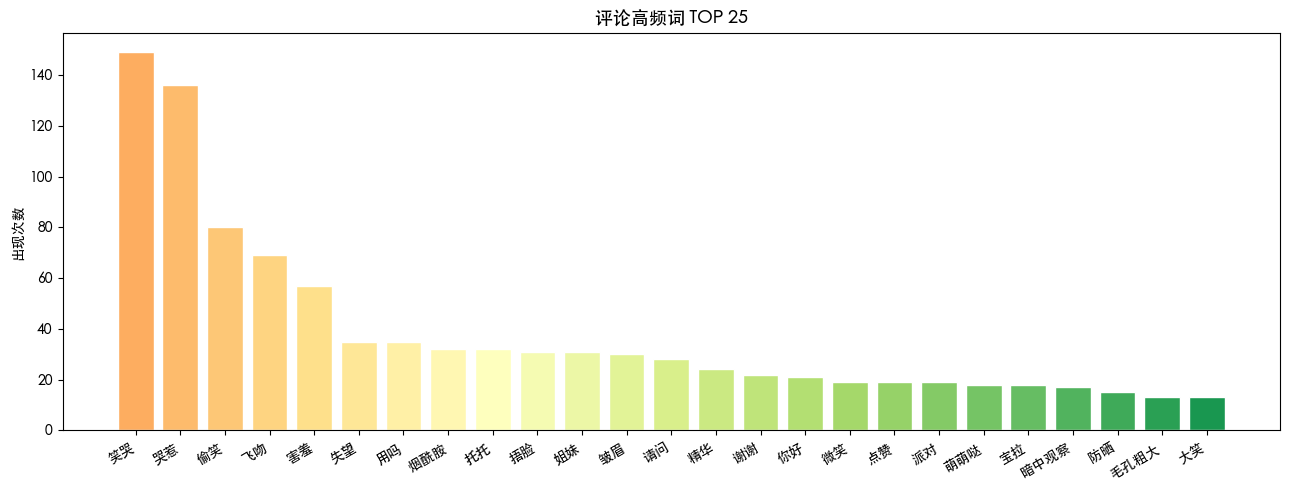

  词语  频次
  笑哭 149
  哭惹 136
  偷笑  80
  飞吻  69
  害羞  57
  失望  35
  用吗  35
 烟酰胺  32
  托托  32
  捂脸  31
  姐妹  31
  皱眉  30
  请问  28
  精华  24
  谢谢  22
  你好  21
  微笑  19
  点赞  19
  派对  19
 萌萌哒  18
  宝拉  18
暗中观察  17
  防晒  15
毛孔粗大  13
  大笑  13


In [11]:
# 用正则切词（不依赖 jieba，适合先快速探索）
stopwords = {'的','了','是','在','我','有','和','就','都','也','很','但',
             '这','那','不','还','可以','感觉','觉得','然后','因为','所以',
             '真的','一个','没有','什么','这个','那个','用了','买了','好像',
             '它','他','她','我们','你们','他们','啊','哦','嗯','吧','呢',
             '哈哈','哦哦','好的','太好了','非常','一些','已经','可能'}

all_text = ' '.join(comments_clean['content'].dropna().tolist())
# 提取2字以上的中文词
words = re.findall(r'[\u4e00-\u9fff]{2,5}', all_text)
words_filtered = [w for w in words if w not in stopwords]

word_freq = Counter(words_filtered).most_common(25)

# 画图
wdf = pd.DataFrame(word_freq, columns=['词语','频次'])
fig, ax = plt.subplots(figsize=(13, 5))
import numpy as np
colors = plt.cm.RdYlGn(np.linspace(0.3, 0.9, 25))
ax.bar(wdf['词语'], wdf['频次'], color=colors, edgecolor='white')
ax.set_title('评论高频词 TOP 25', fontsize=13)
ax.set_ylabel('出现次数')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

print(wdf.to_string(index=False))

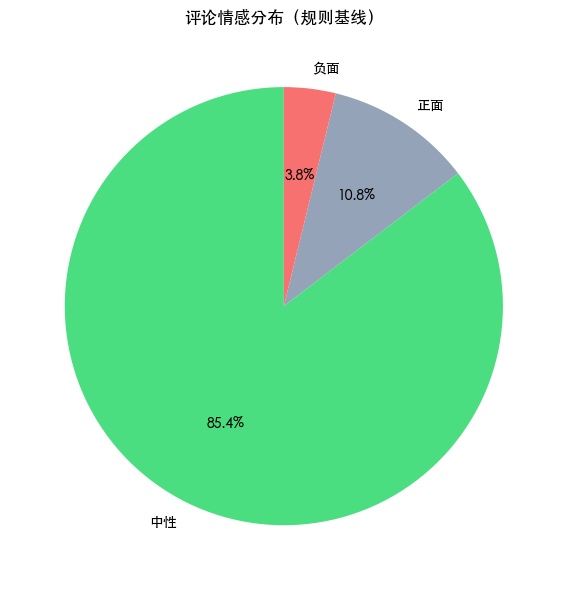

sentiment
中性    1634
正面     207
负面      73
Name: count, dtype: int64

正面率: 10.8%
负面率: 3.8%


In [12]:
pos_words = ['好用','喜欢','推荐','效果好','温和','提亮','改善','惊喜',
             '满意','有效','爱用','好评','棒','完美','神器','必买','值得']
neg_words = ['刺激','烂脸','过敏','失望','无效','浪费','退货','不好用',
             '踩雷','不推荐','差评','起痘','干燥','后悔','智商税','垃圾']

def rule_sentiment(text):
    if pd.isna(text): return '中性'
    p = sum(1 for w in pos_words if w in str(text))
    n = sum(1 for w in neg_words if w in str(text))
    if p > n: return '正面'
    elif n > p: return '负面'
    return '中性'

comments_clean['sentiment'] = comments_clean['content'].apply(rule_sentiment)
dist = comments_clean['sentiment'].value_counts()

fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(dist.values, labels=dist.index, autopct='%1.1f%%',
       colors=['#4ADE80','#94A3B8','#F87171'], startangle=90)
ax.set_title('评论情感分布（规则基线）')
plt.tight_layout()
plt.show()

print(dist)
print(f'\n正面率: {dist.get("正面",0)/len(comments_clean)*100:.1f}%')
print(f'负面率: {dist.get("负面",0)/len(comments_clean)*100:.1f}%')

In [13]:
print(f"""
========== EDA 关键数据 ==========
笔记总数（去重）: {len(contents_dedup)}
评论总数（有效）: {len(comments_clean)}

点赞中位数: {contents_dedup['liked_count_num'].median():.0f}
收藏中位数: {contents_dedup['collected_count'].median():.0f}
评论中位数（笔记维度）: {contents_dedup['comment_count'].median():.0f}

评论长度中位数: {comments_clean['content_len'].median():.0f} 字
零点赞评论占比: {(comments_clean['like_count']==0).mean()*100:.1f}%

情感分布:
{comments_clean['sentiment'].value_counts().to_string()}

TOP 地区: {comments_clean['ip_location'].dropna().value_counts().index[0]}
          {comments_clean['ip_location'].dropna().value_counts().index[1]}（海外第一）
==================================
""")


========== EDA 关键数据 ==========
笔记总数（去重）: 118
评论总数（有效）: 1914

点赞中位数: 136
收藏中位数: 83
评论中位数（笔记维度）: 28

评论长度中位数: 18 字
零点赞评论占比: 65.7%

情感分布:
sentiment
中性    1634
正面     207
负面      73

TOP 地区: 广东
          美国（海外第一）



In [14]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

# 使用哈工大中文RoBERTa（比原版bert-base-chinese效果更好）
MODEL_NAME = "hfl/chinese-roberta-wwm-ext"

print("正在下载模型，第一次需要几分钟...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print("Tokenizer 加载完成 ✓")

# 先测试tokenizer是否正常工作
test_text = "宝拉珍选烟酰胺精华真的很好用，皮肤变白了！"
tokens = tokenizer(test_text, return_tensors='pt', 
                   truncation=True, max_length=128)
print(f"\n测试文本: {test_text}")
print(f"Token数量: {tokens['input_ids'].shape[1]}")
print(f"Token IDs: {tokens['input_ids'][0][:10]}...")

正在下载模型，第一次需要几分钟...


Tokenizer 加载完成 ✓

测试文本: 宝拉珍选烟酰胺精华真的很好用，皮肤变白了！
Token数量: 23
Token IDs: tensor([ 101, 2140, 2861, 4397, 6848, 4170, 6995, 5542, 5125, 1290])...


In [15]:
from transformers import pipeline

# 用现成的情感分析pipeline（基于已fine-tune好的中文情感模型）
# 这个模型已经在中文数据上fine-tune过，可以直接用
sentiment_pipeline = pipeline(
    "text-classification",
    model="lxyuan/distilbert-base-multilingual-cased-sentiments-student",
    device=-1  # CPU运行，如果有GPU改成0
)

# 先测试几条
test_comments = [
    "真的超级好用！皮肤变细腻了很多，强烈推荐！",
    "用了过敏，退货了，太失望了",
    "请问这个和xx牌哪个好？",
    "烟酰胺浓度有点高，敏感皮要慎重",
    "性价比很高，北美买比国内便宜多了"
]

for text in test_comments:
    result = sentiment_pipeline(text)[0]
    label = result['label']
    score = result['score']
    print(f"{'✅' if 'pos' in label.lower() else '❌' if 'neg' in label.lower() else '➖'} "
          f"[{label} {score:.2f}] {text[:30]}...")

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

✅ [positive 1.00] 真的超级好用！皮肤变细腻了很多，强烈推荐！...
❌ [negative 0.97] 用了过敏，退货了，太失望了...
✅ [positive 0.54] 请问这个和xx牌哪个好？...
❌ [negative 0.61] 烟酰胺浓度有点高，敏感皮要慎重...
✅ [positive 0.97] 性价比很高，北美买比国内便宜多了...


In [16]:
import pandas as pd
from tqdm.notebook import tqdm

# 取前500条先跑（全跑CPU很慢，先验证流程）
sample = comments_clean['content'].dropna().head(500).tolist()

results = []
batch_size = 32

print("开始批量情感分析...")
for i in tqdm(range(0, len(sample), batch_size)):
    batch = sample[i:i+batch_size]
    # 截断超长文本
    batch = [text[:512] for text in batch]
    try:
        preds = sentiment_pipeline(batch)
        results.extend(preds)
    except Exception as e:
        # 遇到问题的batch填充中性
        results.extend([{'label': 'neutral', 'score': 0.5}] * len(batch))

# 整理结果
bert_df = comments_clean.head(500).copy()
bert_df['bert_label'] = [r['label'] for r in results]
bert_df['bert_score'] = [r['score'] for r in results]

# 统一标签名
label_map = {
    'positive': '正面', 'negative': '负面', 'neutral': '中性',
    'POSITIVE': '正面', 'NEGATIVE': '负面', 'NEUTRAL': '中性'
}
bert_df['bert_sentiment'] = bert_df['bert_label'].map(label_map).fillna('中性')

print("\n=== BERT 情感分布（前500条）===")
print(bert_df['bert_sentiment'].value_counts())

开始批量情感分析...


  0%|          | 0/16 [00:00<?, ?it/s]


=== BERT 情感分布（前500条）===
bert_sentiment
正面    237
负面    215
中性     48
Name: count, dtype: int64


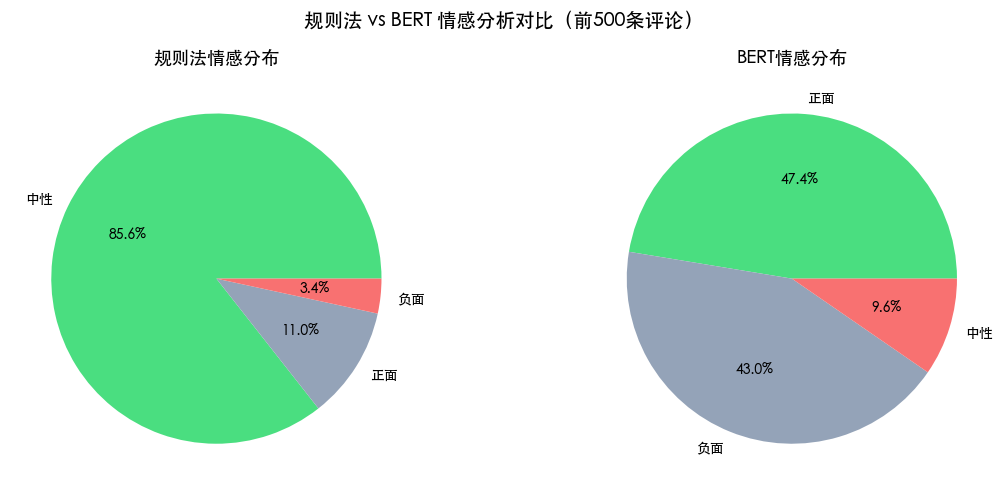


两者分歧案例数: 408

分歧样例（规则=中性 但BERT有判断）:
  文本: 原来老师当年是这个意思啊...
  规则: 中性 → BERT: 正面

  文本: 我也有哦 呵呵...
  规则: 中性 → BERT: 正面

  文本: @玧其尼 @不想取名 @某人在星空破晓 真不行了感觉成绩出来后可以拍...
  规则: 中性 → BERT: 负面

  文本: @关你西红柿 @onlyhan 难怪语文老师给我画那么多圈，原来是暗恋我...
  规则: 中性 → BERT: 负面

  文本: @@TLGDD...
  规则: 中性 → BERT: 正面



In [17]:
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import font_manager

cjk_font_candidates = [
    'Heiti TC', 'Songti SC', 'PingFang SC', 'Arial Unicode MS',
    'Noto Sans CJK SC', 'Microsoft YaHei', 'SimHei'
]
available_fonts = {font.name for font in font_manager.fontManager.ttflist}
for font_name in cjk_font_candidates:
    if font_name in available_fonts:
        matplotlib.rcParams['font.family'] = 'sans-serif'
        matplotlib.rcParams['font.sans-serif'] = [font_name, 'DejaVu Sans']
        break
matplotlib.rcParams['axes.unicode_minus'] = False

# 取前500条的规则法结果做对比
rule_dist = comments_clean.head(500)['sentiment'].value_counts()
bert_dist = bert_df['bert_sentiment'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

colors = ['#4ADE80', '#94A3B8', '#F87171']

axes[0].pie(rule_dist.values, labels=rule_dist.index,
            autopct='%1.1f%%', colors=colors)
axes[0].set_title('规则法情感分布', fontsize=13)

axes[1].pie(bert_dist.values, labels=bert_dist.index,
            autopct='%1.1f%%', colors=colors)
axes[1].set_title('BERT情感分布', fontsize=13)

plt.suptitle('规则法 vs BERT 情感分析对比（前500条评论）', fontsize=14)
plt.tight_layout()
plt.show()

# 找出两者分歧最大的案例
merged = comments_clean.head(500)[['content','sentiment']].copy()
merged['bert_sentiment'] = bert_df['bert_sentiment'].values
disagreements = merged[merged['sentiment'] != merged['bert_sentiment']]
print(f"\n两者分歧案例数: {len(disagreements)}")
print("\n分歧样例（规则=中性 但BERT有判断）:")
sample_dis = disagreements[disagreements['sentiment']=='中性'].head(5)
for _, row in sample_dis.iterrows():
    print(f"  文本: {str(row['content'])[:40]}...")
    print(f"  规则: {row['sentiment']} → BERT: {row['bert_sentiment']}\n")